<h1> B Data Reduction </h1>

# Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact
import numpy as np
import warnings
import statistics as stt
#import bamboolib as bam
#from brokenaxes import brokenaxes
import os
from scipy import stats
from scipy.optimize import curve_fit
from numpy import arange

# Functions to calculate averages of one measurement point

In [55]:
#Functions to calculate averages of one measurement point


#-------------------------------
# Loading & select different type of data, z.b B, C, U
#-------------------------------

def dirFiles(fDir, ending):
    fNames = []
    for i in os.listdir(fDir):
        if i.endswith(ending):
            fNames.append(i)
    return fNames

def selSmpType(dataFiles, smp):
    l = []
    for file in dataFiles:    
        if smp in file.split('_')[1]:
            l.append(file)
    return l


#-------------------------------
# read the number from Neptune filename
#-------------------------------

def getfilenumber(datafile, simbel):
    res = []
    for i in datafile:
        res.append(float(i.split(simbel)[0]))
    return res


#-------------------------------
# Outlier Correction and Data Conversion from str to float
#-------------------------------
def outlierCorrection(measurement, factorSD):
    element_signal = np.array(measurement)
    mean = np.mean(element_signal, axis=0)
    sd = np.std(element_signal, axis=0)
    return [x for x in measurement if (x > mean - factorSD * sd) or (x < mean + factorSD * sd)]


def data_convert(data):
    data_float = []
    fil =  (data.str.contains('L|IC|C|H') == True)
    endnum = data[fil].index[0]
    for i in data[0:endnum]:
        data_float.append(float(i))
    return data_float


#-------------------------------
#B11 background substact
#-------------------------------

def calculateSingleFile_B11(filename, bg_11B, factorSD):
#upload data:
    df = pd.read_csv('data/2022-11-04 Boron measurements/' + filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
#calculate average signal and average backgroud:

    B11_data_float = data_convert(df['11B']) #conversion to float required, as numbers are stored as str
    fils = []
    filw = []
        
    for i in B11_data_float:
        if (i > bg_11B) == True:
            fils.append(i)
        else:
            filw.append(i)

    B_11_aver = np.mean(outlierCorrection(fils, factorSD))
    B_11_backg_aver = np.mean(outlierCorrection(filw, factorSD))
    res = B_11_aver - B_11_backg_aver
    return(res)


#-------------------------------
# B10 background substact for IC
#-------------------------------

def calculateSingleFile_B10_IC(filename, bg_10B, factorSD):
#upload data:
    df = pd.read_csv('data/2022-11-04 Boron measurements/' + filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
#calculate average signal and average backgroud:

    B10_data_float = data_convert(df['10B']) #conversion to float required, as numbers are stored as str
    fils = []
    filw = []
        
    for i in B10_data_float:
        if (i > bg_10B) == True:
            fils.append(i)
        else:
            filw.append(i)

    B_10_aver = np.mean(outlierCorrection(fils, factorSD))
    B_10_backg_aver = np.mean(outlierCorrection(filw, factorSD))
    res = B_10_aver - B_10_backg_aver
    return(res)


#-------------------------------
# B10 background substact for FC
#-------------------------------

def calculateSingleFile_B10_FC(filename, bg_10B, factorSD):
#upload data:
    df = pd.read_csv('data/2022-11-04 Boron measurements/' + filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
#calculate average signal and average backgroud:
    B10_data_float = data_convert(df['10B']) #conversion to float required, as numbers are stored as str
    B_interference_left = data_convert(df['9.9'])
    B_interference_right = data_convert(df['10.2'])
    
    B10_data = outlierCorrection(B10_data_float, 2)
    B_interference_left_res = outlierCorrection(B_interference_left, 2)
    B_interference_right_res = outlierCorrection(B_interference_right, 2)
    
    B_interference_left_res_aver = sum(B_interference_left_res)/len(B_interference_left_res)
    B_interference_right_res_aver = sum(B_interference_right_res)/len(B_interference_right_res)

    B10_interference = (B_interference_right_res_aver - B_interference_left_res_aver)*(10-9.9)/(10.2-9.9)
    
    fils = []
    filw = []    
    for i in B10_data:
        if (i > bg_10B) == True:
            fils.append(i)
        else:
            filw.append(i)
    B_10_backg_aver = np.mean(outlierCorrection(filw, factorSD))
    
    B_10_aver = np.mean(B10_data)
    
    res=B_10_aver-B_10_backg_aver-B10_interference
    return(res)

#-------------------------------
# average valye calculation
#-------------------------------
def calculate_aver(dataFiles, IC):
    res = []
    for i in dataFiles:
        if IC == True:
            aver = calculateSingleFile_B11(i, 0.005, 2)/calculateSingleFile_B10_IC(i, 0.0005, 2)
        else:
            aver = calculateSingleFile_B11(i, 0.005, 2)/calculateSingleFile_B10_FC(i, 0.0005, 2)
        Neptune_res = {'sequence': i, 'average':aver}
        res.append(Neptune_res)
        df = pd.DataFrame(res)
        
    return df

#-------------------------------
# regression based on the level from 2-5 you chosed
#-------------------------------

def regressline(x, y, number):
    if number==5:
        def objective(x, a, b, c, d, e, f):
	        return (a * x) + (b * x**2) + (c * x**3) + (d * x**4) + (e * x**5) + f
        popt, _ = curve_fit(objective, x, y)
        a, b, c, d, e, f = popt
        print('y = %.5f * x + %.5f * x^2 + %.5f* x^3 + %.5f* x^4 + %.5f* x^5 + %.5f' % (a, b, c, d, e, f))
        x_line = arange(min(x), max(x), 1)
        y_line = objective(x_line, a, b, c, d, e, f) 
        
    if number==4:
        def objective(x, a, b, c, d, e):
	        return (a * x) + (b * x**2) + (c * x**3) + (d * x**4) + e
        popt, _ = curve_fit(objective, x, y)
        a, b, c, d, e = popt
        print('y = %.5f * x + %.5f * x^2 + %.5f* x^3 + %.5f* x^4 +  %.5f' % (a, b, c, d, e))
        x_line = arange(min(x), max(x), 1)
        y_line = objective(x_line, a, b, c, d, e)     
        
    if number == 3:
        def objective(x, a, b, c):
	        return (a * x) + (b * x**2) + c
        popt, _ = curve_fit(objective, x, y)
        a, b, c = popt
        print('y = %.5f * x + %.5f * x^2 + %.5f' % (a, b, c))
        x_line = arange(min(x), max(x), 1)
        y_line = objective(x_line, a, b, c)
        
    if number == 2:
        def objective(x, a, b):
	        return (a * x) + b
        popt, _ = curve_fit(objective, x, y)
        a, b = popt
        print('y = %.5f * x + %.5f' % (a, b))
        x_line = arange(min(x), max(x), 1)
        y_line = objective(x_line, a, b)
        

        
    plt.scatter(x,y)
    plt.plot(x_line, y_line, '--', color='red')
    return plt.show()

#  load all .exp files and Calculate averages

In [56]:
dataFiles = dirFiles('data/2022-11-04 Boron measurements', 'exp')
dataFiles.sort()

dataFiles_A = selSmpType(dataFiles, 'A')
dataFiles_B = selSmpType(dataFiles, 'B')
dataFiles_C = selSmpType(dataFiles, 'C')
dataFiles_D = selSmpType(dataFiles, 'D')
dataFiles_U = selSmpType(dataFiles, 'U')
dataFiles_BCDU = [i for i in dataFiles if i not in dataFiles_A]

calculate_aver(dataFiles_BCDU, IC=False)    

/opt/anaconda3/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


,sequence,average
0,003_B.exp,7.744009
1,004_B.exp,7.749350
2,005_C.exp,7.558284
3,006_C.exp,7.572121
4,007_D.exp,6.660408
...,...,...
410,429_U.exp,7.697428
411,430_U.exp,7.696710
412,431_U.exp,7.696943
413,432_U.exp,7.751641


# Use A get the regression line

/opt/anaconda3/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


y = 0.00103 * x + -0.00000 * x^2 + 7.57464


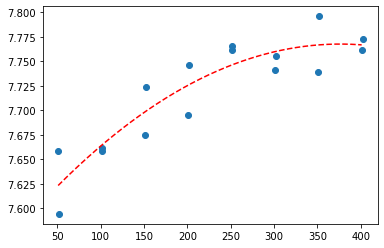

In [70]:
y = calculate_aver(dataFiles_A, IC=False)['average'][2:]
x = getfilenumber(dataFiles_A, '_')[2:]

regressline(x,y,3)

# # #sign the regression value to samples

In [71]:
y_value = objective(55, a, b, c, d, e, f)
y_value


dataFiles = dirFiles('data/2022-11-04 Boron measurements', 'exp')
dataFiles.sort()

dataFiles = selSmpType('B')

dataFiles

res = []
for i in dataFiles:
    aver = calculateSingleFile_B11(i, 0.005, 2)/calculateSingleFile_B10_IC(i, 0.0005, 2)
    Neptune_res = {'sequence': i, 'average':aver}
    res.append(Neptune_res)

x_b = getfilenumber(pd.DataFrame(res)['sequence'], '_')

def offset(datafile):
    res = []
    for i in datafile:
        res.append(objective(i, a, b, c, d, e, f))
    return res

offset(x_b)


TypeError: selSmpType() missing 1 required positional argument: 'smp'

# Laser log file

In [11]:
df_Laser = pd.read_csv('data/Seq_log_20221104_191152.csv', header=0)
Laser_sequece = df_Laser[' Sequence Number'].dropna()
res_laser = []
dfN = pd.DataFrame(res)

for i in dfN['sequence']:
    Nep_index = float(i.split('_')[0])
    mapping = Laser_sequece[Laser_sequece==Nep_index].index[0]
    
    res_laser.append([i, df_Laser.loc[mapping, ' Laser Energy (mJ)'], df_Laser.loc[mapping, ' Spot Size (um)'], 
                      df_Laser.loc[mapping, ' Laser HV (kV)']])
pd.DataFrame(res_laser).rename(columns = {0:'Sample Name', 1: ' Laser Energy (mJ)', 2: ' Spot Size (um)', 3: ' Laser HV (kV)'})

,Sample Name,Laser Energy (mJ),Spot Size (um),Laser HV (kV)
0,001_A.exp,63.920,23.0,22.970
1,002_A.exp,65.034,60.0 x 60.0,23.243
2,051_A.exp,65.310,108.0 x 108.0,23.125
3,052_A.exp,65.225,60.0 x 60.0,23.308
4,101_A.exp,65.023,108.0 x 108.0,23.291
5,102_A.exp,64.606,60.0 x 60.0,23.540
6,151_A.exp,64.728,108.0 x 108.0,23.320
7,152_A.exp,65.286,60.0 x 60.0,23.296
8,201_A.exp,65.198,160.0 x 160.0,23.213
9,202_A.exp,65.121,60.0 x 60.0,23.321


In [12]:
df_Laser

,Timestamp,Sequence Number,SubPoint Number,Vertix Number,Comment,X(um),Y(um),Intended X(um),Intended Y(um),Scan Velocity (um/s),...,Spot Size (um),Spot Angle (deg),MFC1 (ml/min),MFC2 (ml/min),Cell Pressure (kPa),Z(um),Laser Mode,Laser HV (kV),Laser Energy (mJ),On-Sample Fluence (J.cm⁻²)
0,2022-11-04 19:11:52.899,1.0,1.0,NaN,nist,140752,63216,NaN,NaN,NaN,...,23.0,0,348.791281,6.024414,8.038547,0,Compex_EGY_NGR,22.970,63.920,2.809
1,2022-11-04 19:11:52.939,NaN,NaN,NaN,NaN,140323,63315,NaN,NaN,10000.0,...,23.0,0,348.791281,6.024414,8.038547,0,Compex_EGY_NGR,22.970,63.920,2.809
2,2022-11-04 19:12:06.191,NaN,NaN,NaN,NaN,12015,93101,12015.479492,93101.218750,NaN,...,23.0,0,351.118788,5.897461,7.282579,0,Compex_EGY_NGR,22.970,63.920,2.809
3,2022-11-04 19:12:51.741,NaN,NaN,NaN,NaN,12015,93101,NaN,NaN,NaN,...,60.0 x 60.0,0,344.433396,5.989258,6.737290,0,Compex_EGY_NGR,22.960,64.600,2.883
4,2022-11-04 19:13:18.705,NaN,NaN,NaN,NaN,12015,93101,NaN,NaN,NaN,...,60.0 x 60.0,0,344.879088,5.953125,6.786862,0,Compex_EGY_NGR,23.241,65.038,2.783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2161,2022-11-05 4:06:45.321,NaN,NaN,NaN,NaN,12524,92801,NaN,NaN,10000.0,...,60.0 x 60.0,0,345.968560,5.908203,6.786862,0,Compex_EGY_NGR,23.319,65.299,2.856
2162,2022-11-05 4:06:45.433,NaN,NaN,NaN,NaN,12524,92801,12524.419922,92800.632812,NaN,...,60.0 x 60.0,0,345.621910,5.915039,6.811647,0,Compex_EGY_NGR,23.319,65.299,2.856
2163,2022-11-05 4:07:30.441,NaN,NaN,NaN,NaN,12524,92801,NaN,NaN,NaN,...,60.0 x 60.0,0,343.789617,5.925781,6.824040,0,Compex_EGY_NGR,23.170,65.820,2.923
2164,2022-11-05 4:07:57.429,NaN,NaN,NaN,NaN,12524,92801,NaN,NaN,NaN,...,60.0 x 60.0,0,343.591531,5.899414,7.047113,0,Compex_EGY_NGR,23.356,64.956,2.811


# Testing

In [13]:
results = {'Laser Energy (mJ)': res_energy, 
           'Spot Size (um)': res_spotsize, 'Laser HV (kV)': res_HV}

Laser_res= pd.DataFrame(results)
resss = pd.concat([Laser_res, dfN.reindex(Laser_res.index)], axis=1)

NameError: name 'res_energy' is not defined

In [14]:
def laser_Cond(smp):
    return resss[resss['sequence'].str.contains(smp)]

laser_Cond('A')

NameError: name 'resss' is not defined

### Some old code

In [ ]:
#check for outliers for signal:
    element_signal = np.array(fils)
    mean = np.mean(element_signal, axis=0)
    sd = np.std(element_signal, axis=0)
    final_list_signal = [x for x in fils if (x > mean - factorSD * sd)]
    final_list_signal = [x for x in final_list_signal if (x < mean + factorSD * sd)]
    
#check for outliers for background:
    element_backg = np.array(filw)
    mean = np.mean(element_backg, axis=0)
    sd = np.std(element_backg, axis=0)
    final_list_backg = [x for x in filw if (x > mean - factorSD * sd)]
    final_list_backg = [x for x in final_list_backg if (x < mean + factorSD * sd)]
    

def calculateSingleFile(filename, bg_10B, factorSD):
#upload data:
    df = pd.read_csv('data/2022-02-15 Boron measurements/' + filename, sep='\t', header=22)  # Hi Jie, I already inserted the additional argument here
#calculate average signal and average backgroud:
    endnum = df['10B'][df['10B'] == 'L3'].index[0]
#    B_10 = []
    fils = []
    filw = []
#    for i in df['10B'][0:endnum]:
#        B_10.append(float(i)) #conversion to float required, as numbers are stored as str
#    for i in B_10:
    for i in df['10B'][0:endnum]:
        meas = float(i)
        if (meas > bg_10B) == True:
            fils.append(meas)
        else:
            filw.append(meas)

#    outlier_corrected_signal =outlierCorrection(fils, factorSD)
#    outlier_corrected_backg =outlierCorrection(filw, factorSD)

#    B_10_aver = sum(outlier_corrected_signal )/len(outlier_corrected_signal )
#    B_10_backg_aver = sum(outlier_corrected_backg)/len(outlier_corrected_backg)

    B_10_aver = np.mean(outlierCorrection(fils, factorSD))
    B_10_backg_aver = np.mean(outlierCorrection(filw, factorSD))
    
    return(B_10_aver, B_10_backg_aver)